<a href="https://colab.research.google.com/github/jy465/COS30019A2B/blob/jiayim1/A2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount Google Drive

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import Libraries

In [19]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

Set Dataset Path

In [20]:
TRAIN_DIR = "/content/drive/MyDrive/A2b/data3a/training"
VAL_DIR = "/content/drive/MyDrive/A2b/data3a/validation"

# Required class names
CLASSES = ["00-none", "01-minor", "02-moderate", "03-severe"]


Data Loading Function

In [21]:
def load_dataset(path, img_size=128):
    X, y = [], []

    for class_name in CLASSES:
        class_path = os.path.join(path, class_name)

        if not os.path.exists(class_path):
            print("⚠ Missing folder:", class_path)
            continue

        for file in os.listdir(class_path):
            file_path = os.path.join(class_path, file)

            img = cv2.imread(file_path)
            if img is None:
                continue

            img = cv2.resize(img, (img_size, img_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = img.flatten()

            X.append(img)
            y.append(CLASSES.index(class_name))

    return np.array(X), np.array(y)


Load Training + Validation Data

In [22]:
X_train, y_train = load_dataset(TRAIN_DIR)
X_val, y_val = load_dataset(VAL_DIR)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))


Training samples: 1419
Validation samples: 248


Train and Save Random Forest (First ML)

In [24]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_val)

print("Random Forest Accuracy:", accuracy_score(y_val, rf_preds))
print(classification_report(y_val, rf_preds))

joblib.dump(rf, "/content/drive/MyDrive/A2b/rf_model.pkl")
print("Random Forest model saved.")



📌 Random Forest Accuracy: 0.5
              precision    recall  f1-score   support

           1       0.59      0.66      0.62        82
           2       0.38      0.28      0.32        75
           3       0.49      0.54      0.51        91

    accuracy                           0.50       248
   macro avg       0.48      0.49      0.48       248
weighted avg       0.49      0.50      0.49       248

Random Forest model saved.


Train and Save SVM (Second ML Model)

In [25]:
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)

svm_preds = svm.predict(X_val)

print("SVM Accuracy:", accuracy_score(y_val, svm_preds))
print(classification_report(y_val, svm_preds))

joblib.dump(svm, "/content/drive/MyDrive/A2b/svm_model.pkl")
print("SVM model saved.")


SVM Accuracy: 0.5120967741935484
              precision    recall  f1-score   support

           1       0.53      0.63      0.58        82
           2       0.39      0.33      0.36        75
           3       0.58      0.55      0.56        91

    accuracy                           0.51       248
   macro avg       0.50      0.51      0.50       248
weighted avg       0.51      0.51      0.51       248

SVM model saved.


Confusion Matrix Helper

In [26]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))


Plot Confusion Matrices

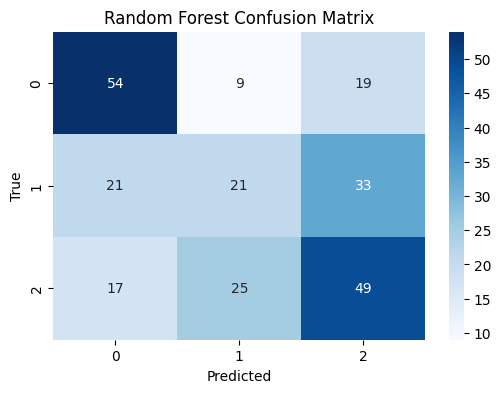

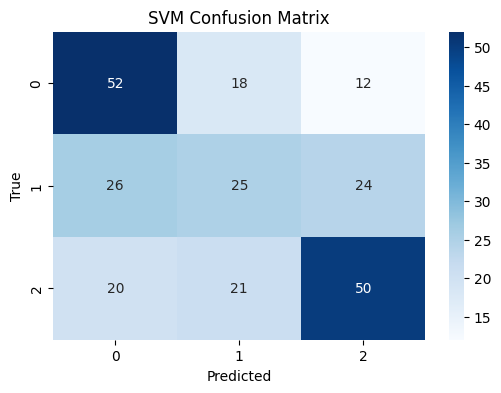

In [27]:
plot_cm(y_val, rf_preds, "Random Forest Confusion Matrix")
plot_cm(y_val, svm_preds, "SVM Confusion Matrix")


Visualize Predictions for Random Forest

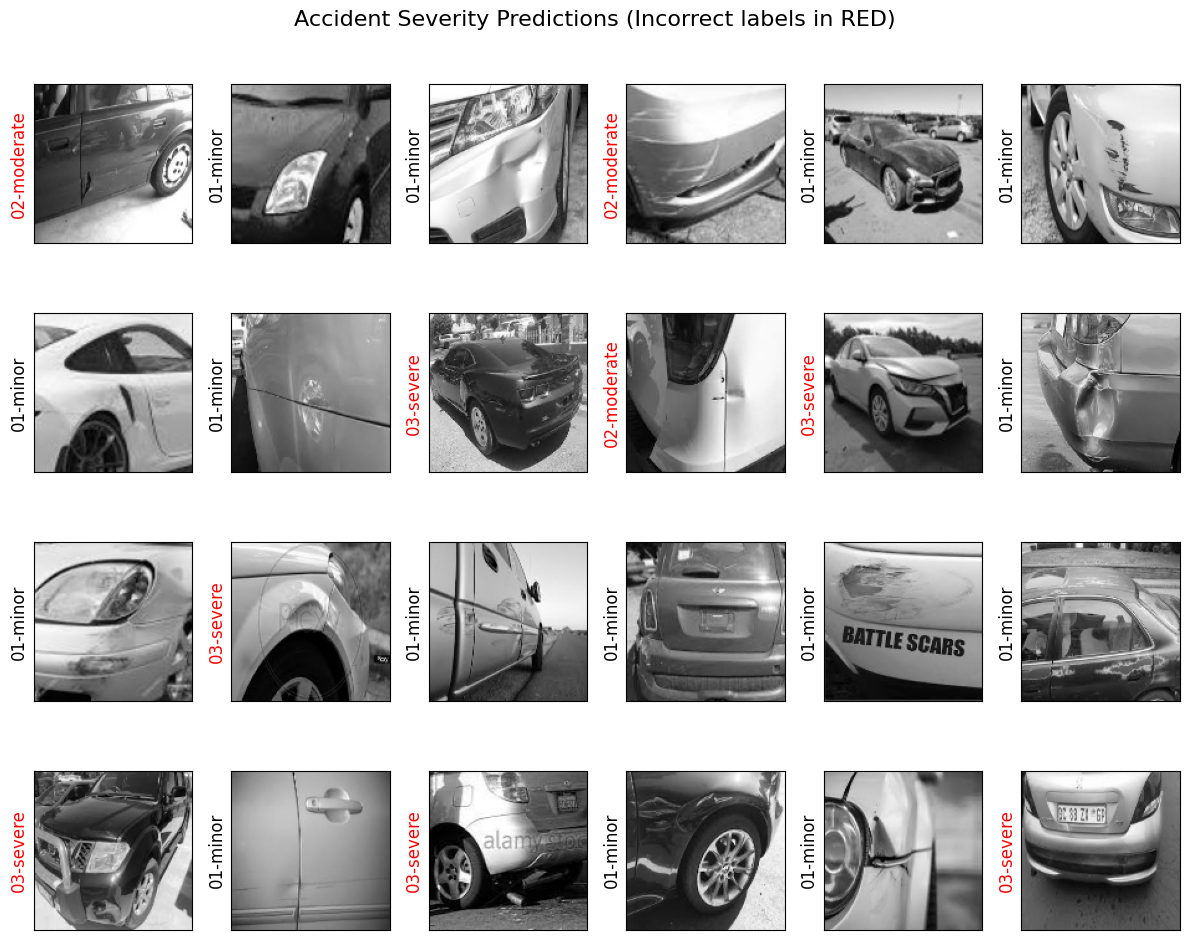

In [28]:
fig, ax = plt.subplots(4, 6, figsize=(12, 10))

for i, axi in enumerate(ax.flat):
    if i >= len(X_val):
        break

    axi.imshow(X_val[i].reshape(128, 128), cmap='gray')
    axi.set_xticks([])
    axi.set_yticks([])

    true_label = CLASSES[y_val[i]]
    pred_label = CLASSES[rf_preds[i]]

    color = 'black' if rf_preds[i] == y_val[i] else 'red'
    axi.set_ylabel(pred_label, color=color, fontsize=12)

fig.suptitle("Accident Severity Predictions (Incorrect labels in RED)", fontsize=16)
plt.tight_layout()
plt.show()


Visualize Predictions for SVM

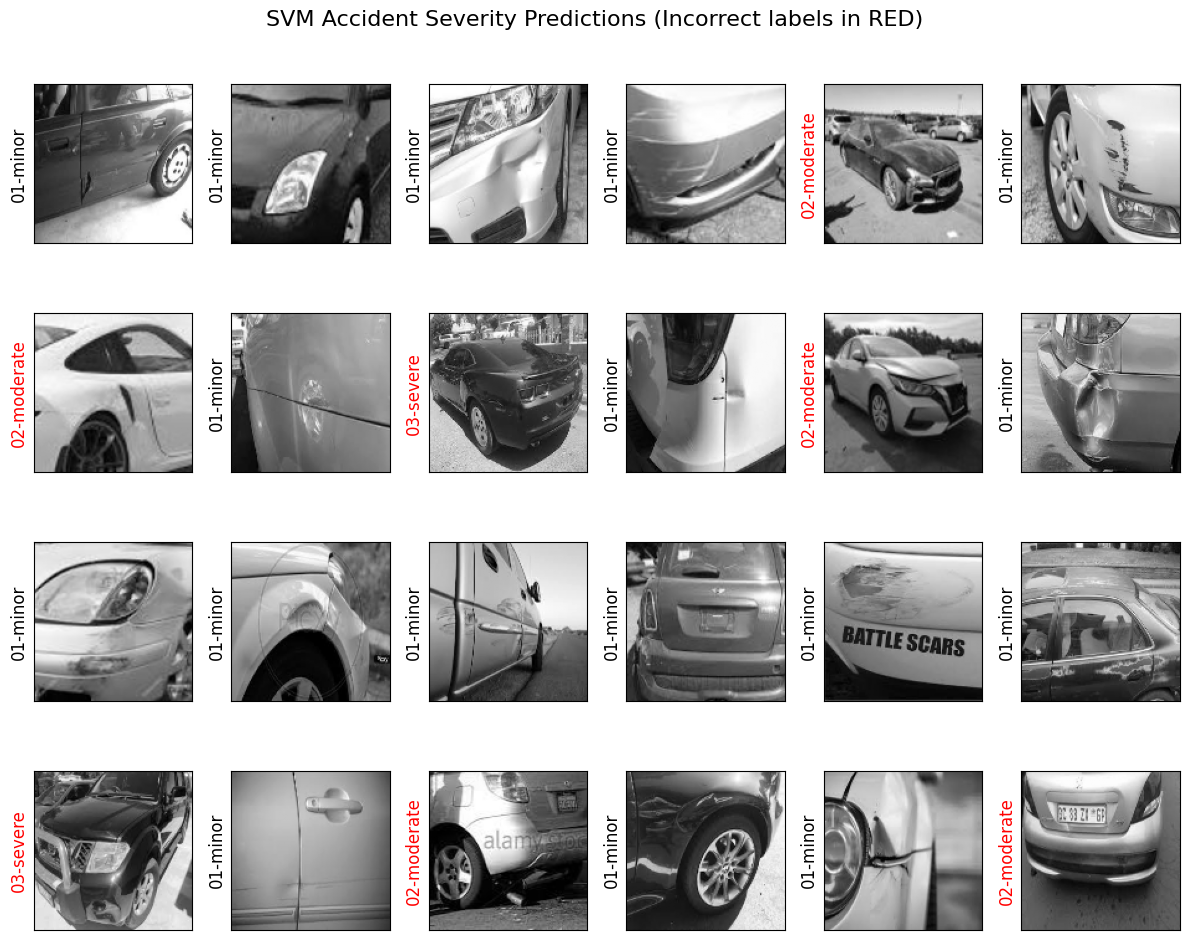

In [29]:
# Visualize SVM predictions (similar to Random Forest visualization)
fig, ax = plt.subplots(4, 6, figsize=(12, 10))

for i, axi in enumerate(ax.flat):
    if i >= len(X_val):
        break

    # Reshape the flattened image back to original size (128x128 in this case)
    axi.imshow(X_val[i].reshape(128, 128), cmap='gray')

    # Remove axis ticks
    axi.set_xticks([])
    axi.set_yticks([])

    # Get true and predicted labels for SVM
    true_label = CLASSES[y_val[i]]
    pred_label = CLASSES[svm_preds[i]]

    # Color the label black if correct, red if incorrect
    color = 'black' if svm_preds[i] == y_val[i] else 'red'

    # Set the label on the image
    axi.set_ylabel(pred_label, color=color, fontsize=12)

# Title for the whole figure
fig.suptitle("SVM Accident Severity Predictions (Incorrect labels in RED)", fontsize=16)

plt.tight_layout()
plt.show()
